# Model Explainability (SHAP)

In [1]:
import shap
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)

from xgboost import XGBClassifier
import joblib

In [3]:
df = pd.read_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\01_Data\Feature_Engineered_Customer_Churn.csv")
df_shap = df.copy()

In [4]:
df_shap.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,ServiceCount,ContractRiskScore,TenureSegment,ChargesSegment,HighRiskFlag,ElectronicCheckFlag,NewCustomerFlag,LongTermCustomerFlag,PremiumCustomerFlag,TotalRiskScore
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,2,3,New,Low,0,1,1,0,0,5
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,4,2,Established,Medium,0,0,0,0,0,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,4,3,New,Medium,0,0,1,0,0,4
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,4,2,Established,Medium,0,0,0,1,0,2
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,2,3,New,High,1,1,1,0,0,6


In [6]:
# Prepare Features and Target
y = df_shap["Churn"]
X = df_shap.drop("Churn", axis=1)

In [7]:
# Remove Customer ID
if "CustomerID" in X.columns:
    X = X.drop("CustomerID", axis=1)

In [8]:
# One-Hot Encode Categorical Variables
X = pd.get_dummies(X, drop_first = True)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [10]:
# Build Final XGBoost Model
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [12]:
# Train Model 
final_model = final_model.fit(X_train, y_train)

In [17]:
# Generate Predictions
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

In [18]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1035    0]
 [   0  374]]


In [22]:
# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 1.0000


In [25]:
# Save Final Model 
joblib.dump(final_model, r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\05_Model\xgboost_churn_model.pkl")

['C:\\Users\\win10\\OneDrive\\Desktop\\Data-Projects\\Portfolio Project\\Customer Churn Prediction\\05_Model\\xgboost_churn_model.pkl']

In [26]:

joblib.dump(X.columns.tolist(), r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\05_Model\feature_names.pkl")

['C:\\Users\\win10\\OneDrive\\Desktop\\Data-Projects\\Portfolio Project\\Customer Churn Prediction\\05_Model\\feature_names.pkl']

In [31]:
model = joblib.load(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\05_Model\\xgboost_churn_model.pkl")
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [29]:
saved_features = joblib.load(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\05_Model\feature_names.pkl")
print(saved_features)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnBinary', 'ARPM', 'CLV_proxy', 'ServiceCount', 'ContractRiskScore', 'HighRiskFlag', 'ElectronicCheckFlag', 'NewCustomerFlag', 'LongTermCustomerFlag', 'PremiumCustomerFlag', 'TotalRiskScore', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TenureSegment_Established', 'TenureSegment_L

In [30]:
# Align Columns 
X = X.reindex(columns=saved_features, fill_value=0)

In [32]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model) 

In [33]:
# Calculate SHAP values
shap_values = explainer.shap_values(X)

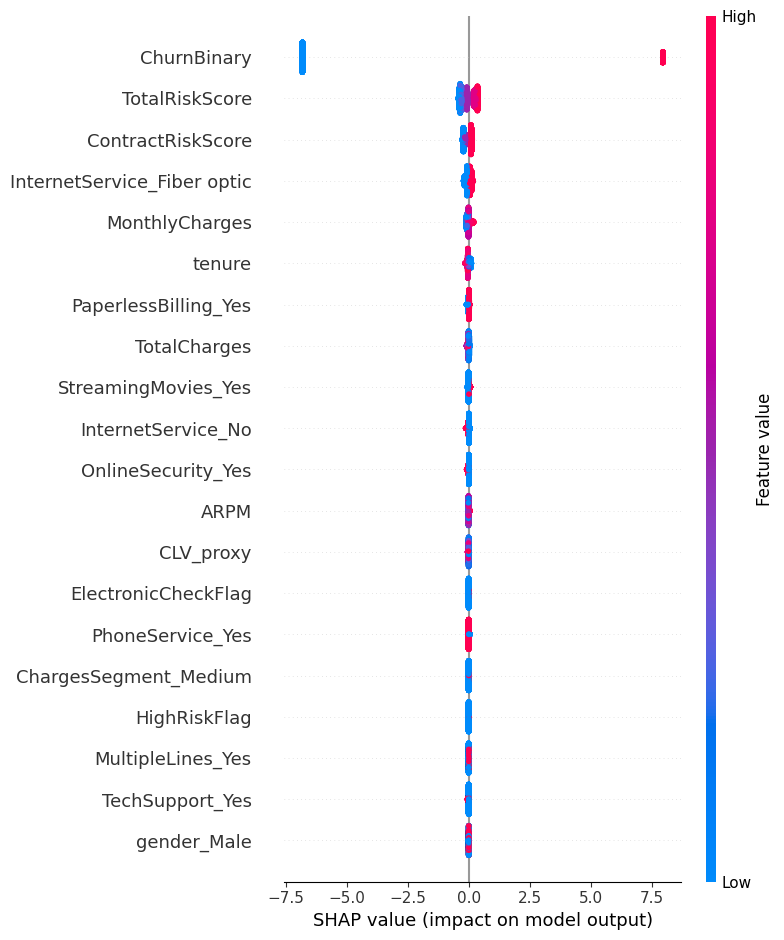

In [34]:
# Global SHAP Summary Plot
shap.summary_plot(shap_values, X)

In [37]:
# Feature Importance Ranking
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

# Sort Features
importance_df = (importance_df.sort_values(by="Importance", ascending=False))
print(importance_df.head(10))

                        Feature  Importance
4                   ChurnBinary    7.125742
14               TotalRiskScore    0.258076
8             ContractRiskScore    0.146876
21  InternetService_Fiber optic    0.102540
2                MonthlyCharges    0.052028
1                        tenure    0.041042
37         PaperlessBilling_Yes    0.019324
3                  TotalCharges    0.018160
34          StreamingMovies_Yes    0.015028
22           InternetService_No    0.013575


C:\Users\win10\AppData\Local\Temp\ipykernel_4056\1582085198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df.head(15), palette="viridis")


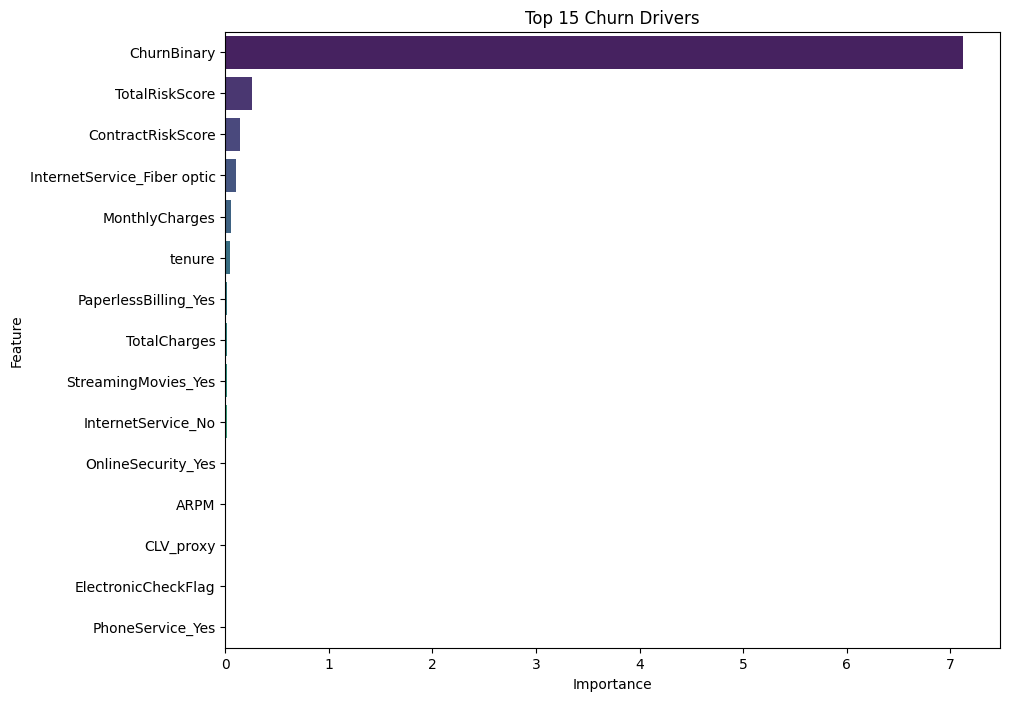

In [38]:
# Executive Chart 
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15), palette="viridis")
plt.title("Top 15 Churn Drivers")
plt.show()

In [40]:
# Save Ranking 
importance_df.to_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\01_Data\feature_importance_ranking.csv", index=False)

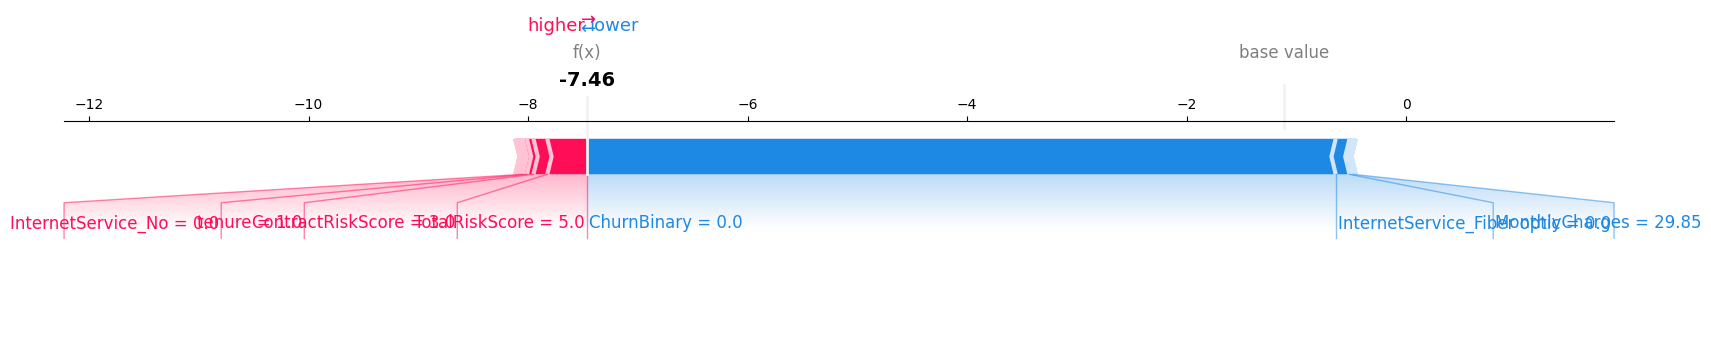

In [41]:
# Individual Customer Explanation
customer_index = 0
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[customer_index], X.iloc[customer_index], matplotlib=True)

In [42]:
# Create Explainable Customer Dataset
predictions = model.predict_proba(X)
probabilities = model.predict_proba(X)[:, 1]

In [45]:
# Create Dataset
customer_results = df.copy()

In [51]:
# Add Predictions
customer_results = X_test.copy()
customer_results["PredictedChurn"] = predictions
customer_results["ChurnProbability"] = probabilities

customer_results.loc[X_test.index, "PredictedChurn"] = predictions
customer_results.loc[X_test.index, "ChurnProbability"] = probabilities


In [52]:
# Add to SHAP Driver
customer_results[
    "TopRiskFactor"
] = (
    pd.DataFrame(
        np.abs(shap_values),
        columns=X.columns
    )
    .idxmax(axis=1)
)

In [53]:
# Retention Recommendation Engine

def generate_recommendation(
    risk_factor
):

    if "ContractRiskScore" in risk_factor:
        return (
            "Offer long-term contract discount"
        )

    elif "MonthlyCharges" in risk_factor:
        return (
            "Offer billing discount"
        )

    elif "ServiceCount" in risk_factor:
        return (
            "Promote bundled services"
        )

    elif "ElectronicCheckFlag" in risk_factor:
        return (
            "Encourage automatic payments"
        )

    elif "Tenure" in risk_factor:
        return (
            "Launch loyalty campaign"
        )

    else:
        return (
            "Contact customer proactively"
        )

In [54]:
# Apply Recommendations

customer_results[
    "RetentionRecommendation"
] = (
    customer_results[
        "TopRiskFactor"
    ]
    .apply(
        generate_recommendation
    )
)

In [55]:
customer_results[
[
"ChurnProbability",
"TopRiskFactor",
"RetentionRecommendation"
]
].head()

,ChurnProbability,TopRiskFactor,RetentionRecommendation
437,0.000214,ChurnBinary,Contact customer proactively
2280,0.000700,ChurnBinary,Contact customer proactively
2235,0.000181,ChurnBinary,Contact customer proactively
4460,0.000551,ChurnBinary,Contact customer proactively
3761,0.000158,ChurnBinary,Contact customer proactively


In [56]:
# Power BI Dashboard Dataset 
customer_results.to_csv(r"C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\Customer Churn Prediction\01_Data\shap_dashboard_data.csv", index=False)

In [57]:
# API Explanation Dataset
api_dataset = (
    customer_results[
        [
            "ChurnProbability",
            "TopRiskFactor",
            "RetentionRecommendation"
        ]
    ]
)

# Save 
api_dataset.to_csv(
    "api_explanations.csv",
    index=False
)